# Phase 0 — Quantpedia Validation Run

**Study:** dual_momentum_turkish_investor · **Gate:** SPEC §6a (mandatory, before any Turkish data)

Reproduces the Quantpedia *Active Dual Momentum GTAA* setup as closely as practical:
9 ETFs (SHY, IEF, UUP, GLD, USO, SPY, EFA, QQQ, EEM), weekly Wednesday close,
L ∈ {10, 25}w, N = 3, absolute filter → **0% cash**, USD only, no costs.
Evaluation window 2008-02-21 → latest (their Figure 5 starts 2008-02-21; their data ends 2026-03-25 — mirrored in the last table).

**PASS criteria (neighborhood — data vendor differs: yfinance vs EODHD):**
blend Sharpe ≈ 0.8–1.0; blend max-DD visibly better than the EW benchmark; both
sub-strategies individually reasonable; equity curve shape qualitatively matches their Figure 5.

This notebook is re-runnable; `phase0_validation.py` is the permanent regression test for all later engine changes.

In [1]:
import numpy as np
import pandas as pd
from phase0_validation import run
from engine import stats

table, checks, curves, blend_weights_frame, blend_turnover = run()
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
table

,perf,st_dev,max_dd,sharpe,calmar,weeks
sub_10w,0.1035,0.1286,-0.1382,0.8048,0.7490,966.0000
sub_25w,0.1110,0.1321,-0.2058,0.8402,0.5393,966.0000
blend,0.1084,0.1221,-0.1239,0.8880,0.8753,966.0000
EW_benchmark,0.0627,0.1080,-0.3278,0.5803,0.1912,966.0000


In [2]:
for k, ok in checks.items():
    print(f"[{'PASS' if ok else 'FAIL'}] {k}")
print()
print("PHASE 0:", "PASS" if all(checks.values()) else "FAIL")
print(f"blend mean weekly one-way turnover: {blend_turnover:0.3f} "
      f"(at 10 bps -> ~{blend_turnover * 10 * 52 / 100:0.2f}%/yr cost drag, relevant for Phase 1)")

[PASS] blend Sharpe in [0.8, 1.0] neighborhood (>=0.75)
[PASS] blend Sharpe > EW Sharpe
[PASS] blend max-DD visibly better than EW (<= 0.75x)
[PASS] both sub-strategies Sharpe > EW

PHASE 0: PASS
blend mean weekly one-way turnover: 0.301 (at 10 bps -> ~1.56%/yr cost drag, relevant for Phase 1)


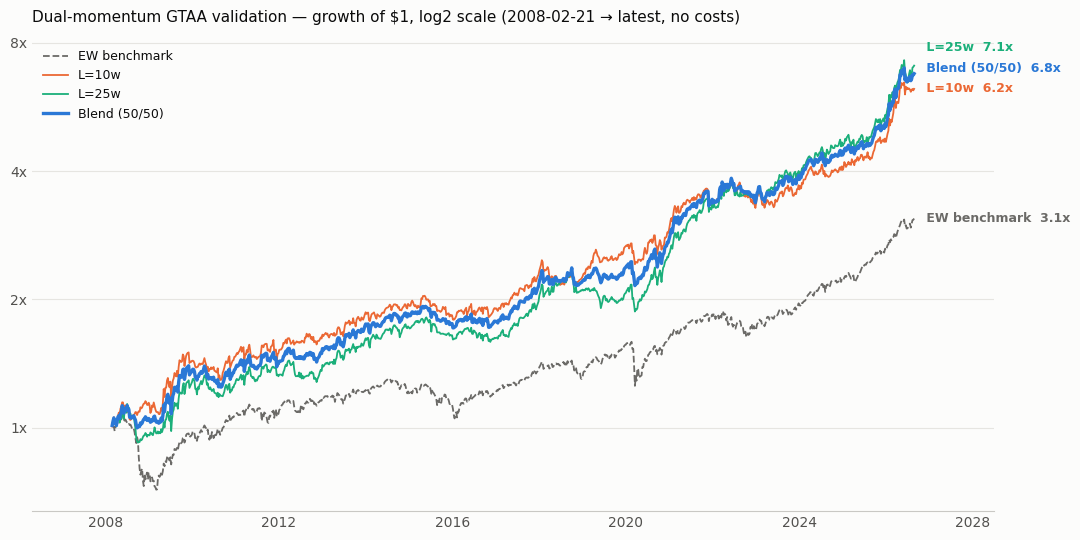

In [3]:
import matplotlib.pyplot as plt

SURFACE = "#fcfcfb"
COL = {"blend": "#2a78d6", "sub_10w": "#eb6834", "sub_25w": "#1baf7a", "EW_benchmark": "#6b6a67"}
LW = {"blend": 2.4, "sub_10w": 1.3, "sub_25w": 1.3, "EW_benchmark": 1.3}
LABEL = {"blend": "Blend (50/50)", "sub_10w": "L=10w", "sub_25w": "L=25w", "EW_benchmark": "EW benchmark"}

fig, ax = plt.subplots(figsize=(11, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for name in ["EW_benchmark", "sub_10w", "sub_25w", "blend"]:
    c = curves[name]
    ax.plot(c.index, np.log2(c.values), color=COL[name], lw=LW[name],
            ls="--" if name == "EW_benchmark" else "-", label=LABEL[name])

last = sorted(((np.log2(curves[n].iloc[-1]), n) for n in curves), key=lambda t: t[0])
prev = None
for y, n in last:
    if prev is not None and y - prev < 0.16:
        y = prev + 0.16
    prev = y
    ax.annotate(f" {LABEL[n]}  {curves[n].iloc[-1]:0.1f}x",
                xy=(curves[n].index[-1], y), xytext=(6, 0),
                textcoords="offset points", va="center",
                color=COL[n], fontsize=9, fontweight="bold")

ymax = int(np.ceil(max(np.log2(c.values).max() for c in curves.values())))
ax.set_yticks(range(0, ymax + 1))
ax.set_yticklabels([f"{2**k}x" for k in range(0, ymax + 1)])
ax.grid(axis="y", color="#e6e5e1", lw=0.8)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#c9c8c4")
ax.tick_params(colors="#52514e", length=0)
ax.set_title("Dual-momentum GTAA validation — growth of $1, log2 scale (2008-02-21 → latest, no costs)",
             color="#0b0b0b", fontsize=11, loc="left", pad=12)
ax.legend(loc="upper left", frameon=False, fontsize=9, labelcolor="#0b0b0b")
ax.margins(x=0.10)
plt.tight_layout()
plt.show()

In [4]:
# Exact Quantpedia window mirror (their data ends 2026-03-25)
rows = [stats(curves[n].pct_change().dropna().loc[:"2026-03-25"], n) for n in
        ["sub_10w", "sub_25w", "blend", "EW_benchmark"]]
pd.DataFrame(rows)

,perf,st_dev,max_dd,sharpe,calmar,weeks
sub_10w,0.0995,0.1274,-0.1382,0.7814,0.7202,943.0000
sub_25w,0.1034,0.1303,-0.2058,0.7939,0.5026,943.0000
blend,0.1026,0.1208,-0.1239,0.8493,0.8283,943.0000
EW_benchmark,0.0575,0.1081,-0.3278,0.5314,0.1753,943.0000


## Results & Interpretation

**PHASE 0: PASS** (2026-08-22) — gate cleared on the first run, with zero parameter or engine tuning.

- **Blend Sharpe 0.89** (0.85 on the exact Quantpedia window ending 2026-03-25) vs their reported "close to 0.9" — inside the pass neighborhood despite a different data vendor (yfinance adjusted closes vs EODHD).
- **Blend max-DD -12.4% vs EW benchmark -32.8%** (0.38x) — "visibly better than EW" satisfied by a wide margin; Calmar 0.88 vs 0.19.
- **Both sub-strategies individually reasonable:** L=10w Sharpe 0.80, L=25w 0.84, both well above EW (0.58). The blend beats both subs on Sharpe and DD — the diversification-across-horizons effect Quantpedia reports.
- **Curve shape qualitatively matches their Figure 5:** 2008 crash sidestepped (absolute filter parks slots in 0% cash), steady climb with 2015-16 and 2021-23 plateaus, strong 2020-21 and 2024-26 legs; final multiples ~6-7x vs EW ~3x on log2 scale.
- **Cost preview for Phase 1:** blend mean weekly one-way turnover 0.30 -> at 10 bps that is ~1.6%/yr of drag (~-0.13 Sharpe). Costs will matter but should not change the qualitative picture; 25 bps sensitivity will be the stress case.

**Mechanics validated:** no look-ahead (weights decided at Wednesday close t earn returns t -> t+1), W-WED resample with <=5-day forward-fill, failed-filter slots to 0% cash, sleeve eligibility = RoC computable at t.

**Gate consequence:** the engine is trusted. Phase 1 (Version B, USD implementable universe, costs on) may proceed; no Turkish data entered before this gate, per SPEC section 6a. `phase0_validation.py` stays as the permanent regression test — rerun it after ANY engine change.